<a href="https://colab.research.google.com/github/Carmen10-171/03MIAR_Algoritmos-de-Optimizacion/blob/main/01MIAR_ACT_Dataset_Banca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="viu_logo.png" width="200">

# 01MIAR - Actividad Dataset
## Análisis de clientes potenciales en banca  
### Bank Marketing Dataset (UCI Machine Learning Repository)
Autor: Mª Carmen Copé Soler


#### 1. Dataset escogido y objetivos del estudio

El dataset escogido contiene información sobre campañas de marketing realizadas por una entidad bancaria (Banco de Portugal) para ofrecer depósitos a plazo a clientes potenciales.  

Portal oficial del dataset:

https://archive.ics.uci.edu/dataset/222/bank+marketing

![image.png](attachment:9441e7d5-d822-4268-bb25-4e9eb3b1b012.png)

- El dataset utilizado es:

- **bank-additional-full.csv**: 41.188 registros y 20 variables. Registros de clientes y campañas, con variables demográficas, financieras, de contacto y de contexto económico.

Los interrogantes que intentamos resolver a continuación son los siguientes:

- ¿Qué perfiles de clientes son los más frecuentes en las campañas?
- ¿Qué tipo de contacto es el más habitual?
- ¿Qué variables influyen más en la contratación del producto?
- ¿Qué combinación de factores se asocia a mayor tasa de éxito?
- ¿Cómo se distribuye la actividad de campañas a lo largo del tiempo?
- ¿Qué patrones pueden ser útiles para una empresa de servicios IT que analice clientes potenciales en banca?

- ** Interpretación de negocio para banca y servicios IT

Los resultados del análisis permiten extraer conclusiones aplicables a empresas IT que trabajan con banca:

- La duración de la llamada es el factor más determinante: campañas más largas tienden a convertir mejor.
- Los clientes con historial previo de campañas (`previous`) muestran mayor probabilidad de conversión.
- El contexto económico influye: variables como `euribor3m` y `emp.var.rate` correlacionan con la contratación.
- El tipo de contacto es clave: ciertos canales muestran mayor eficacia.
- El dataset está desbalanceado, por lo que un sistema de scoring debe incluir técnicas de rebalanceo.

Estos hallazgos permiten diseñar:

- Modelos predictivos para priorizar clientes con mayor probabilidad de conversión.
- Sistemas de automatización de campañas basados en segmentación inteligente.
- Reglas de negocio para optimizar duración, canal y frecuencia de contacto.

##   2. Preparación del dataset
#### 2.1 Lectura del fichero

In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import requests
import zipfile
from io import BytesIO

import sys
print(sys.executable)
!{sys.executable} -m pip install scikit-learn

/usr/bin/python3


#### Localización automática del recurso de descarga
#### Descargamos y leemos el dataset desde UCI

In [2]:
# ============================================
# 2. DESCARGA DEL HTML DE LA PÁGINA
# ============================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
r = requests.get(url)
z = zipfile.ZipFile(BytesIO(r.content))

with z.open("bank-additional/bank-additional-full.csv") as f:
    bank_dataset = pd.read_csv(f, sep=';')

display(bank_dataset.head(5))
print(bank_dataset.shape)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


(41188, 21)


#### 2.2 Depuración y limpieza del Dataset

In [3]:
# ============================================
# 2.2 EXTRACCIÓN DE ENLACES REALES DE DATOS
# ============================================

# Inspeccionamos el dataframe para detectar posibles irregularidades en los datos
bank_dataset.info()

# Contamos los nan values
print(bank_dataset.isnull().sum())

# Revisamos el tipo de dato de las columnas del dataframe
print(bank_dataset.dtypes)


# Cast de las variables de tipo object a category
cols_categorical = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome', 'y'
]

bank_dataset[cols_categorical] = bank_dataset[cols_categorical].astype('category')

cols_numeric = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

bank_dataset[cols_numeric].describe()

# Comprobamos de nuevo tipos de datos
print(bank_dataset.dtypes)

# Comprobamos que no quedan nan values (en este dataset normalmente no hay)
print(bank_dataset.isnull().sum())

# Columnas numéricas reales del dataset Bank Marketing (UCI)
cols_numeric = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

# Verificación automática
missing = set(cols_numeric) - set(model_dataset.columns)
missing


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

NameError: name 'model_dataset' is not defined

## Exploración y visualización de la información
#### 3.1. Actividad por “zona geográfica” (perfil de cliente)

/tmp/ipykernel_842/2005181177.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_job = bank_dataset.groupby('job')['age'].count()


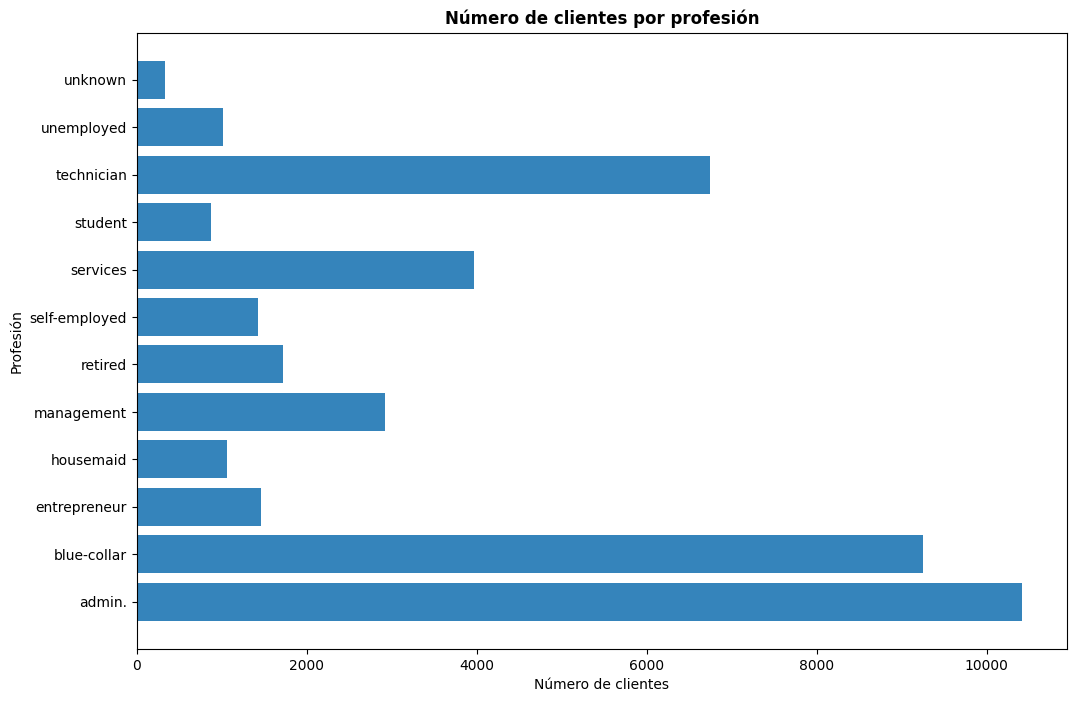

In [4]:
# ============================================
# 3.1 SELECCIÓN AUTOMÁTICA DEL RECURSO
# ============================================
# Conteo de clientes por profesión
df_job = bank_dataset.groupby('job')['age'].count()
jobs = bank_dataset['job'].cat.categories

y_rang = np.arange(jobs.size)
width = 0.8
opacity = 0.9

fig, ax = plt.subplots()
bars = ax.barh(y_rang, df_job.values, width, alpha=opacity)

ax.set_yticks(y_rang)
ax.set_yticklabels(jobs)

ax.set_title('Número de clientes por profesión', weight='bold')
ax.set_ylabel('Profesión')
ax.set_xlabel('Número de clientes')

ax.figure.set_size_inches(12, 8)
plt.show()


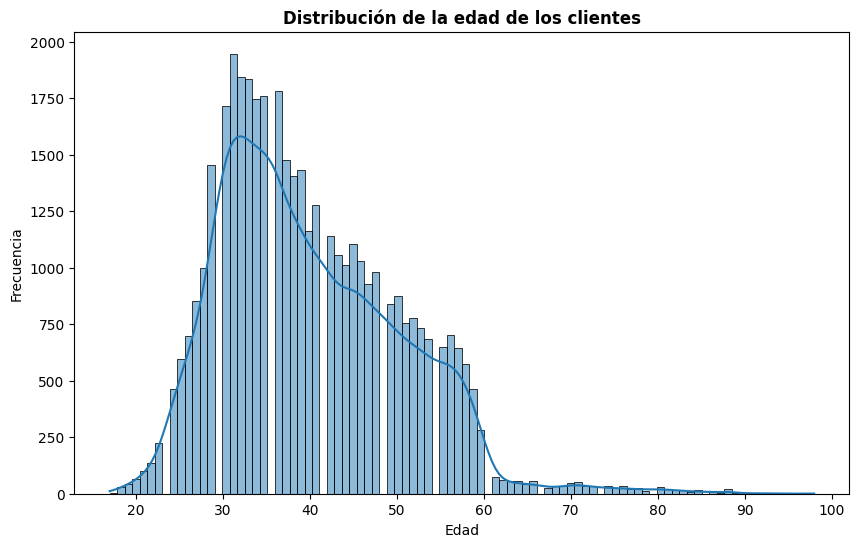

In [5]:
# Distribución de la edad
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(bank_dataset['age'], kde=True, ax=ax)
ax.set_title('Distribución de la edad de los clientes', weight='bold')
ax.set_xlabel('Edad')
ax.set_ylabel('Frecuencia')
plt.show()

#### 3.2. Actividad según otros factores

/tmp/ipykernel_842/1357851905.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bank_dataset.groupby(['marital', 'contact']).age.count().unstack(),


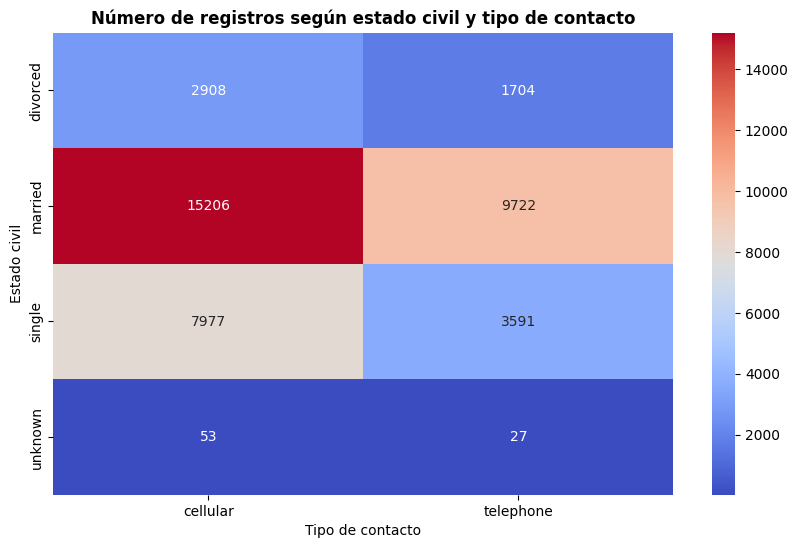

In [6]:
# ============================================
# 3.2. ACTIVIDAD SEGÚN OTROS FACTORES
# ============================================
# Mapa de calor: número de registros según estado civil y tipo de contacto
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    bank_dataset.groupby(['marital', 'contact']).age.count().unstack(),
    annot=True, fmt=".0f", cmap='coolwarm', ax=ax
)
ax.set_title("Número de registros según estado civil y tipo de contacto", weight='bold')
ax.set_xlabel('Tipo de contacto')
ax.set_ylabel('Estado civil')
plt.show()

/tmp/ipykernel_842/2440329577.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  types = bank_dataset.groupby('contact').size() / bank_dataset['contact'].count() * 100


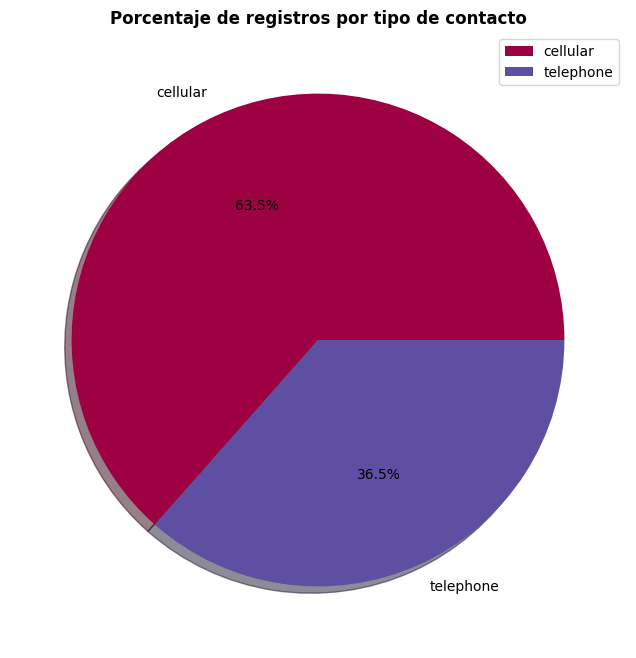

In [7]:
# ============================================
# Porcentaje de registros por tipo de contacto
# ============================================
types = bank_dataset.groupby('contact').size() / bank_dataset['contact'].count() * 100
labels = types.index.tolist()
values = types.values.tolist()

fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.get_cmap('Spectral')
colors = [cmap(i) for i in np.linspace(0, 1, len(labels))]
ax.pie(values, labels=labels, autopct='%1.1f%%', shadow=True, colors=colors)

ax.set_title('Porcentaje de registros por tipo de contacto', weight='bold')
ax.legend(loc='best')
plt.show()

#### 3.3. “Precio” por zona geográfica (resultado y contexto)
- Analizamos tasa de éxito (y) por segmentos y cómo se relaciona con variables de contexto económico
    

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


/tmp/ipykernel_842/168528845.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_job = bank_dataset.groupby('job')['y'].value_counts(normalize=True).unstack().fillna(0)


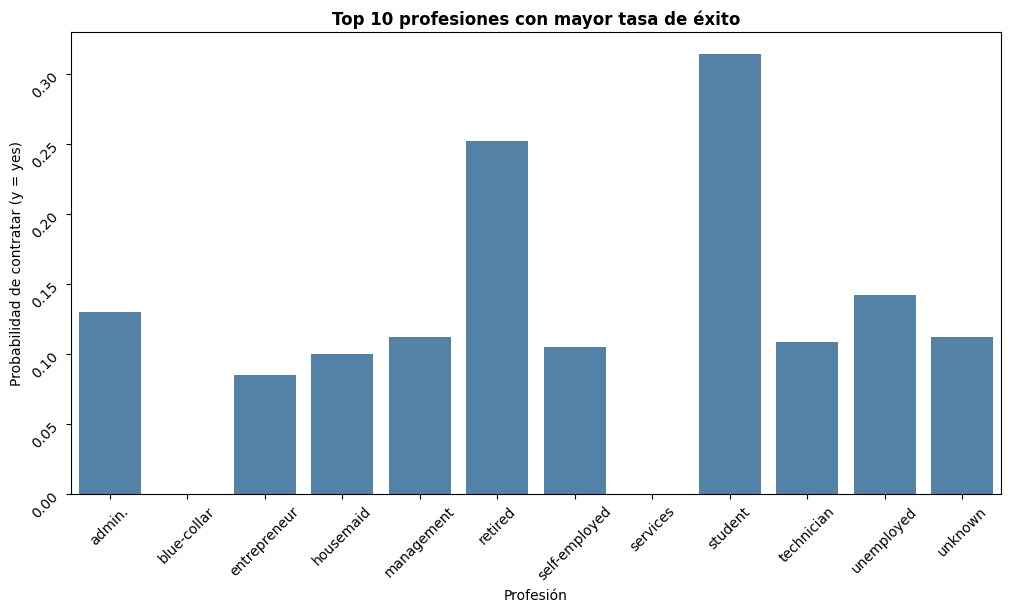

In [8]:
# ============================================
# 3.3.  Resultado de campaña por segmentos
# ============================================

# Tasa de éxito global
success_rate = bank_dataset['y'].value_counts(normalize=True) * 100
print(success_rate)
# Tasa de éxito por profesión (top 10)
conversion_job = bank_dataset.groupby('job')['y'].value_counts(normalize=True).unstack().fillna(0)
conv_yes = conversion_job['yes'].sort_values(ascending=False)[:10]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=conv_yes.index, y=conv_yes.values, color='steelblue', ax=ax)
ax.tick_params(labelrotation=45)
ax.set_title('Top 10 profesiones con mayor tasa de éxito', weight='bold')
ax.set_xlabel('Profesión')
ax.set_ylabel('Probabilidad de contratar (y = yes)')
plt.show()

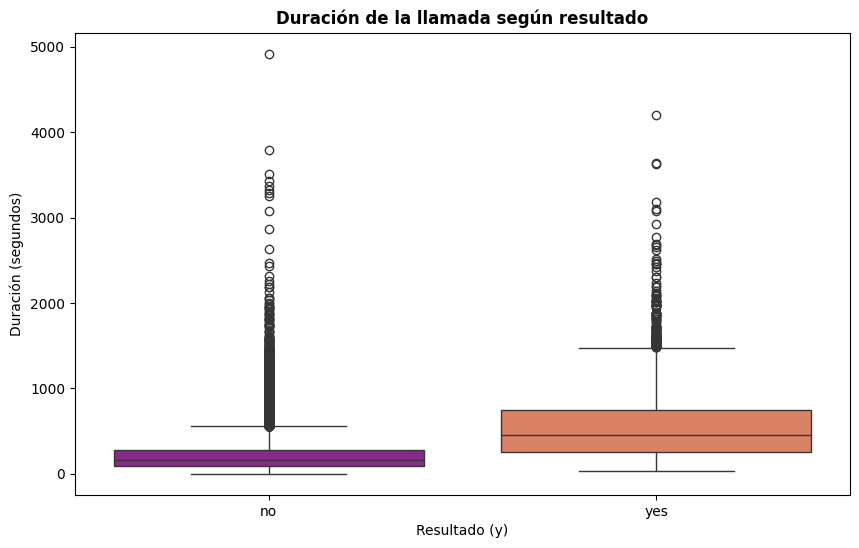

In [9]:
# Boxplot: duración de llamada por resultado
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x=bank_dataset['y'], y=bank_dataset['duration'],
            hue=bank_dataset['y'], palette='plasma', dodge=False, ax=ax)
ax.set_title("Duración de la llamada según resultado", weight='bold')
ax.set_xlabel('Resultado (y)')
ax.set_ylabel('Duración (segundos)')
ax.grid(False)
plt.show()

#### 3.4. Resultado según otros factores


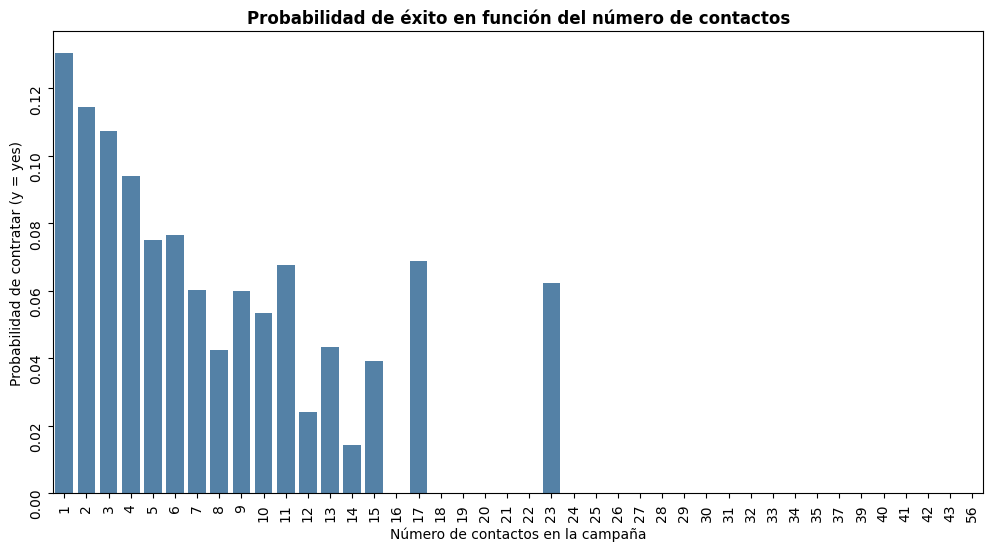

In [10]:
## 3.4. Resultado según otros factores
# Precio equivalente: probabilidad de éxito según número de contactos en la campaña
n_contacts = bank_dataset.groupby('campaign')['y'].value_counts(normalize=True).unstack().fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=n_contacts.index, y=n_contacts['yes'].values,
            color='steelblue', ax=ax)
ax.tick_params(labelrotation=90)
ax.set_title("Probabilidad de éxito en función del número de contactos", weight='bold')
ax.set_xlabel('Número de contactos en la campaña')
ax.set_ylabel('Probabilidad de contratar (y = yes)')
ax.grid(False)
plt.show()

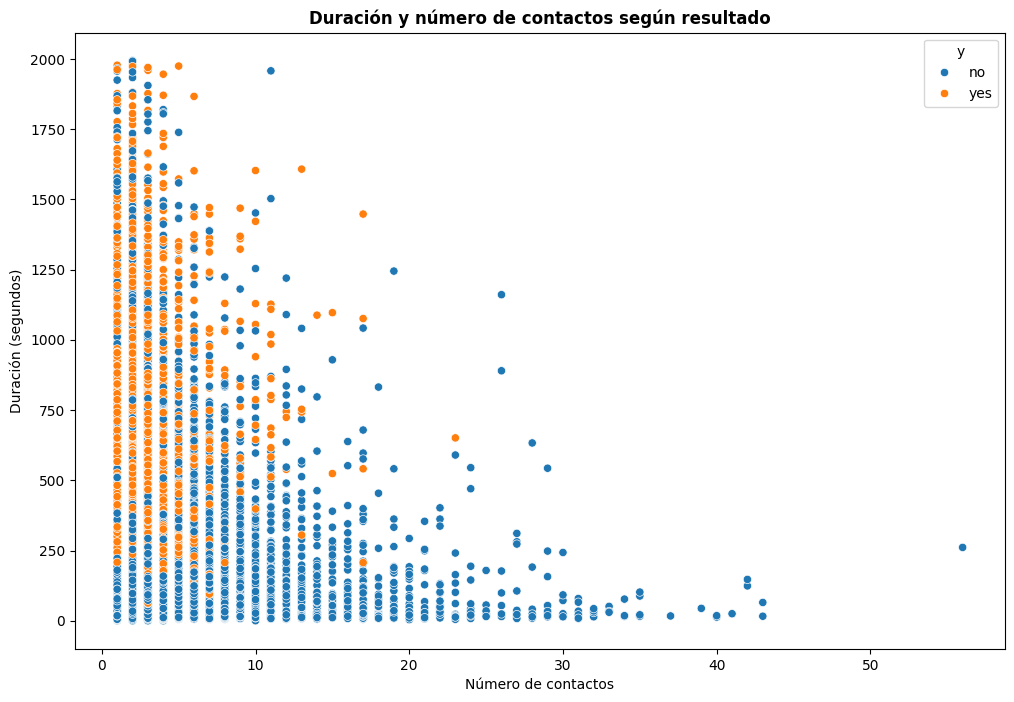

In [11]:
# Scatter: duración vs número de contactos, filtrando outliers de duración
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    x="campaign",
    y="duration",
    hue="y",
    data=bank_dataset[bank_dataset['duration'] < 2000],
    ax=ax
)
ax.set_title("Duración y número de contactos según resultado", weight='bold')
ax.set_xlabel('Número de contactos')
ax.set_ylabel('Duración (segundos)')
plt.show()

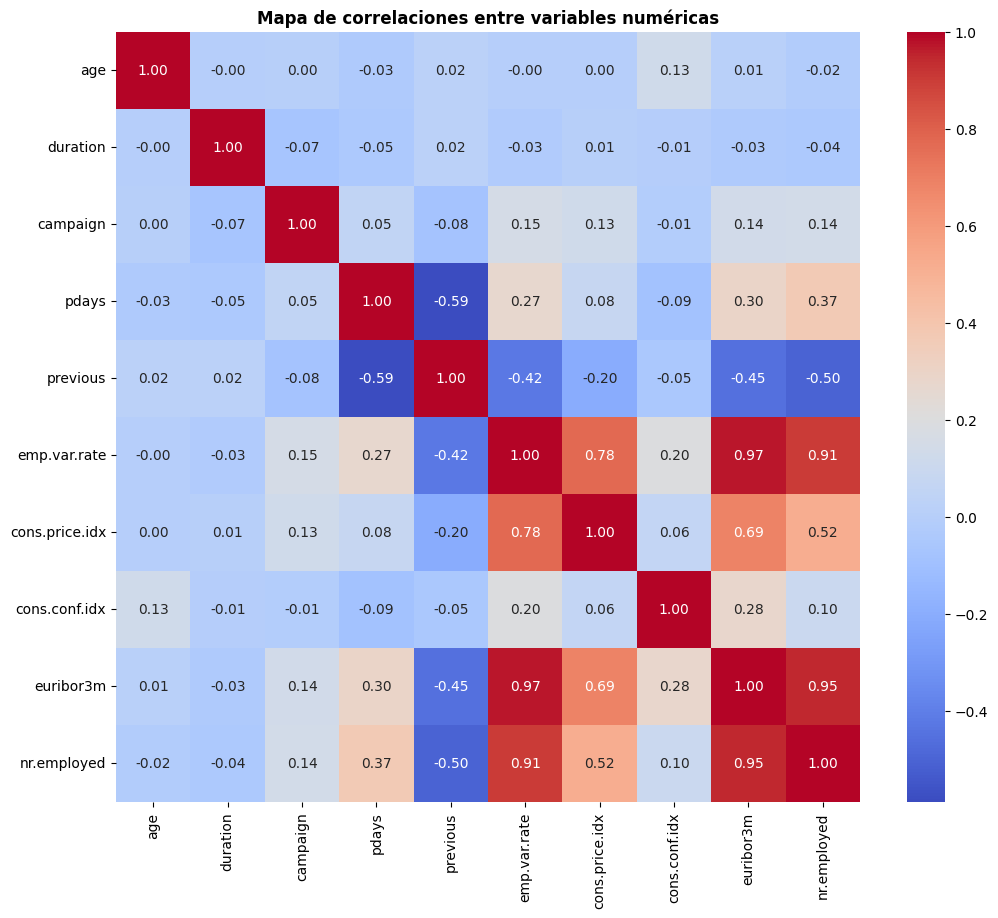

In [12]:
# Mapa de calor de correlaciones numéricas
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(bank_dataset[cols_numeric].corr(), annot=True, fmt=".2f",
            cmap='coolwarm', ax=ax)
ax.set_title("Mapa de correlaciones entre variables numéricas", weight='bold')
plt.show()

#### 3.5. Preparación de los datos para un modelo predictivo

En esta sección preparamos el dataset para un modelo de clasificación que permita predecir si un cliente contratará el depósito bancario (`y = yes`).  
Este proceso es habitual en empresas de servicios IT que desarrollan sistemas de scoring y segmentación para banca.

In [13]:
model_dataset = bank_dataset.copy()

# Convertimos la variable objetivo ANTES de hacer dummies
model_dataset['y'] = model_dataset['y'].map({'yes': 1, 'no': 0})

# One-hot encoding EXCLUYENDO la variable objetivo
model_dataset = pd.get_dummies(model_dataset, columns=model_dataset.columns.drop('y'), drop_first=True)

display(model_dataset.head())
print(model_dataset.shape)

,y,age_18,age_19,age_20,age_21,age_22,age_23,age_24,age_25,age_26,...,nr.employed_4991.6,nr.employed_5008.7,nr.employed_5017.5,nr.employed_5023.5,nr.employed_5076.2,nr.employed_5099.1,nr.employed_5176.3,nr.employed_5191.0,nr.employed_5195.8,nr.employed_5228.1
0,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


(41188, 2122)


y
0    88.734583
1    11.265417
Name: proportion, dtype: float64


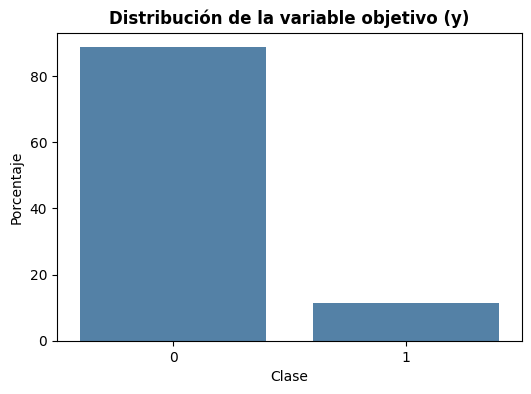

In [14]:
class_balance = model_dataset['y'].value_counts(normalize=True) * 100
print(class_balance)

fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=class_balance.index, y=class_balance.values, color='steelblue', ax=ax)
ax.set_title("Distribución de la variable objetivo (y)", weight='bold')
ax.set_xlabel("Clase")
ax.set_ylabel("Porcentaje")
plt.show()


In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Intentar convertir TODAS las columnas a numéricas
model_dataset_converted = model_dataset.apply(pd.to_numeric, errors='coerce')

# 2. Seleccionar solo columnas numéricas reales
cols_numeric = model_dataset_converted.select_dtypes(include=['float64', 'int64']).columns.tolist()

print("Columnas numéricas detectadas:", cols_numeric)

# 3. Escalar solo si hay columnas numéricas
if len(cols_numeric) == 0:
    print("⚠️ No hay columnas numéricas en el dataset. No se puede escalar.")
else:
    scaler = StandardScaler()
    model_dataset[cols_numeric] = scaler.fit_transform(model_dataset_converted[cols_numeric])
    display(model_dataset[cols_numeric].head())

Columnas numéricas detectadas: ['y']


,y
0,-0.356309
1,-0.356309
2,-0.356309
3,-0.356309
4,-0.356309


Columna objetivo detectada: y


/tmp/ipykernel_842/722521243.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


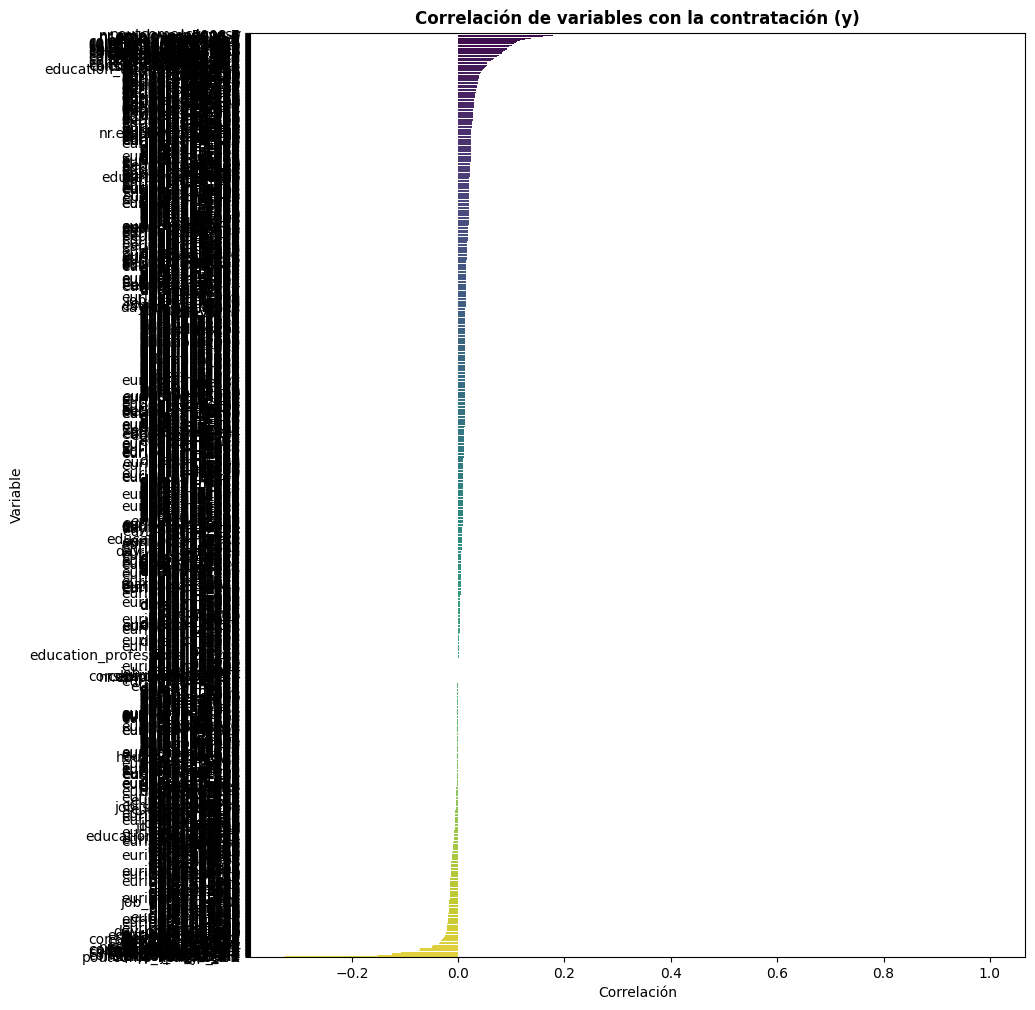

In [16]:
# Detectar la columna objetivo automáticamente
target_col = [col for col in model_dataset.columns if col.startswith('y')][0]
print("Columna objetivo detectada:", target_col)
corr_target = model_dataset.corr()[target_col].sort_values(ascending=False)
plt.figure(figsize=(10, 12))

colors = sns.color_palette('viridis', len(corr_target))

sns.barplot(
    x=corr_target.values,
    y=corr_target.index,
    palette=colors
)

plt.title(f"Correlación de variables con la contratación ({target_col})", weight='bold')
plt.xlabel("Correlación")
plt.ylabel("Variable")
plt.show()

## 4. Conclusión

El análisis del Bank Marketing Dataset permite comprender qué perfiles de clientes son más propensos a contratar productos bancarios y qué factores influyen en su decisión. Se observa la importancia de:

- La duración de la llamada y el número de contactos en la campaña.
- Determinadas profesiones y estados civiles.
- El tipo de contacto (teléfono, móvil, etc.).
- El contexto económico en el que se realizan las campañas.

Este tipo de análisis es muy relevante para entidades financieras y empresas de servicios IT que desean automatizar la segmentación de clientes,que buscan optimizar procesos de captación y optimizar campañas de marketing.  
La actividad ha permitido aplicar técnicas de preparación de datos, exploración, visualización y análisis crítico sobre un caso realista del sector bancario.


## Declaración uso IA
Se han utilizado herramientas de IA generativa para poder representar las gráficas y visualizar los datos